# DCOR

### = Diffusion coefficients determined by Concentration profiles from an Optical Response

This notebook shows how optical data (RGB intensities) from images can be used to evaluate effective diffusion coefficients as well as concentration dependent diffusion coefficients from Boltzmann-Matano analysis. The experimental setup to acquiring the necessary data is shown in the figure below. All details can be found in the corresponding publication and its supplementary material: https://doi.org/10.1016/j.nanoen.2026.111797. For questions don't hesitate to contact Monica Mead (monica.mead@imw.uni-stuttgart.de)

#### If you use the here presented code in whole or in parts please cite the repository and/or the above mentioned paper.

<figure>
  <img src="Figure1_final.png" width="1000">
  <figcaption>Fig. 1. (a) Schematic of optical operando microscopy of a three-electrode setup of the cathode material of interest (LMO). (b) Sample geometry from a diametric and cross-sectional perspective. If the concentration outside the photoresist (SU-8) pattern differs to underneath it, a concentration gradient is generated underneath the photoresist since Li-ions have to diffuse laterally. The established concentration profile is visible by a change in color. (c) Experimental images of the initial state t0 (top) and after generating a concentration profile ti (bottom). The areas from which the RGB-intensities are taken for calibration and diffusion measurement are indicated by dotted and dashed lines, respectively (scale bar: 50 µm). (d) Frame-averaged RGB-intensities versus Li-concentration in LMO from calibration outside the photoresist pattern. (e) RGB-intensity profile as a result of the Li-ion concentration gradient underneath the photoresist pattern. From M. Mead, N. Kerner, R. Talei, Y. Joshi, G. Schmitz, Lithium transport from operando microscopy: Kinetic trapping in lithium manganese oxide, Nano Energy 151 (2026) 111797. https://doi.org/10.1016/j.nanoen.2026.111797.</figcaption>
</figure>

### Content of this notebook:

This notebook has three parts: 

1 Correction of illumination and camera artefacts over the image and over time

2 Tracking of the diffusion front to determine the effective diffusion coefficient

3 Determination of concetration dependent diffusion coefficients from concentration profiles that were determined from the RGB intensities by comparing to the RGB intensities of the calibration images at known concentrations

### Evaluated image areas:

The image below shows roughly the areas that were evaluated:

<figure>
  <img src="evaluation_areas.png" width="400">
</figure>

1 Is the area that was analysed for the evaluation of the Li transport in LMO. Images were recorded at different times while applying a constant voltage. This removes Li from the thin film. Because of the concentration gradient at the edge of the photoresist there is a lateral movement of Li ions underneath the photoresist. If we track this area over time we see the diffusion front moving. This is what is evaluated to determine transport coefficients.

2 Is the area that is analysed to capture calibration images. For this a constant current is applied and images are recorded at set points in time. This way we know the concentration in the thin film at each point in time (assuming that all measured current is a result of a removal of Li from the thin film and is not a result of formation of CEI/other current producing reactions). This gives us a set of RGB intensities for each concetration (Figure 1d above).

3 Is a reference area to determine the changes over time during both measurements. Within the evaluated times it is expected that this area has a constant concentration and therefore there should be no optical changes that are caused by changes in Li concentration. All changes of intensities over time in this area should be due to other factors. Therefore this area is used to correct all other images so that all changes in those corrected images is only due to changes in Li concentration. Practically this is already included in the image set of the diffusion measurement (1) and has to be added seperately in the case for the calibration measurement (2).

In [1]:
#import necessary packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from skimage import io
#from symfit import Fit, Parameter, Variable
import os
from scipy.ndimage import gaussian_filter1d

from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn import model_selection
from scipy import interpolate
from scipy.optimize import curve_fit
from IPython.display import display

from scipy.special import erf
from scipy.signal import savgol_filter

C:\Users\monica.mead\AppData\Local\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


## Image corrections of calibration and diffusion images

### Helper functions for image corrections/displaying:

In [2]:
#this function displays each channel (R,g,B) as a gray scale image
def display_RGB_channels(image, title=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    channels = ['Red', 'Green', 'Blue']

    for i, ax in enumerate(axes):
        channel = image[:, :, i]
        ax.imshow(channel, cmap='gray')
        ax.set_title(f'{channels[i]} Channel')
        ax.axis('off')
    
    if title:
        fig.suptitle(f"{title}", fontsize=16)

    plt.tight_layout()
    
    plt.show()

In [3]:
#polynomial fit to first recorded image to capture inhomogeneities due to camera or illumination effects
def polynomialfit_calim(imcal_int, alpha, title=None):
    channels = ['Red', 'Green', 'Blue']
    
    # Prepare grid and degree of polynomial
    x, y = np.meshgrid(np.arange(imcal_int.shape[1]), np.arange(imcal_int.shape[0]))
    degree = 2

    # Store results for reuse
    results = []

    # Initialize an array to store the fitted data for all channels
    Z_fit_combined = np.zeros_like(imcal_int, dtype=float)

    # Fit a 2D polynomial to each channel and display the fit
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for i, ax in enumerate(axes):
        channel = imcal_int[:, :, i]

        # Flatten the data for fitting
        X = x.flatten()
        Y = y.flatten()
        Z = channel.flatten()

        # Build the design matrix for a 2D polynomial of given degree
        A = np.vstack([X**(p-q) * Y**q for p in range(degree+1) for q in range(p+1)]).T

        # Least squares fit to find coefficients
        coeffs, _, _, _ = np.linalg.lstsq(A, Z, rcond=None)

        # Evaluate the polynomial on the grid
        Z_fit = np.dot(A, coeffs).reshape(channel.shape)

        # Store data for later use
        results.append((X, Y, Z, coeffs, Z_fit))

        # Store the fitted data in the combined array
        Z_fit_combined[:, :, i] = Z_fit

        # Display the fitted surface
        ax.imshow(Z_fit, cmap='gray')
        ax.set_title(f'{channels[i]} Channel Fit')
        ax.axis('off')
    fig.suptitle(f"{title}_2Dfit_2Dplot")

    plt.tight_layout()
    plt.show()

    # Plot intensities from the data with the fitted data in 3D
    fig = plt.figure(figsize=(18, 6))

    for i in range(3):
        ax = fig.add_subplot(1, 3, i+1, projection='3d')
        X, Y, Z, coeffs, Z_fit = results[i]

        # Plot the original data as scatter and the fit as a surface
        ax.scatter(X, Y, Z, color='r', s=1, label='Original Data', alpha=alpha)
        ax.plot_surface(x, y, Z_fit, cmap='viridis')
        
        ax.set_title(f'{channels[i]} Channel: Data & Fit')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Intensity')
        ax.legend()
    fig.suptitle(f"{title}_2Dfit_3Dplot")
    plt.tight_layout()
    plt.show()
    # Now Z_fit_combined holds the fitted data for all channels
    return results, Z_fit_combined
    


In [4]:
#plot RGB intensity profile along the diffusion direction
def plot_profile(dif_length,profile_RGB,plot_step, title=None):
    num=profile_RGB.shape[0]
    
    colorsR = cm.autumn(np.linspace(1, 0, num-1))
    colorsG = cm.summer(np.linspace(1, 0, num-1))
    colorsB = cm.winter(np.linspace(1, 0, num-1))

    for i in range (0,num-1,plot_step):
        plt.scatter(dif_length,profile_RGB[i+1,:,0],color=colorsR[i], marker='x', s=1)
        plt.scatter(dif_length,profile_RGB[i+1,:,1],color=colorsG[i], marker='x', s=1) 
        plt.scatter(dif_length,profile_RGB[i+1,:,2],color=colorsB[i], marker='x', s=1) 
        
        plt.scatter(dif_length, profile_RGB[0,:,0], color='k', marker='x', s=1)
        plt.scatter(dif_length, profile_RGB[0,:,1], color='k', marker='x', s=1)
        plt.scatter(dif_length, profile_RGB[0,:,2], color='k', marker='x', s=1)
        
    #make pretty
    plt.xlabel('length [\u03bcm]',fontsize=16)
    plt.ylabel('RGB intensities',fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.title(f"{title}")
    plt.show()

In [5]:
#correct for the intensity shift over time with reference to an area 3
#--> all intensities are due to concentration changes not other changes e.g. in illumination
def int_shift_time(ref_intensities_t, sigma, title=None):
    shift_intwitht = ref_intensities_t - ref_intensities_t[0]
    
    if np.any(shift_intwitht>10):
        a=np.max(shift_intwitht)
        raise ValueError(f"Intensity shift with time is large! - Max. shift: {a}") 
    
    avg_int_t_blur = gaussian_filter1d(ref_intensities_t, sigma=sigma, axis=0)

    fig, axes = plt.subplots(3, 1, figsize=(6, 8))
    axes[0].plot(ref_intensities_t[:,0], "x",ms =3, color='r', label='ref intensities')
    axes[0].plot(avg_int_t_blur[:,0], "o", ms=4, color='k', label='Gaussian blur')
    axes[0].set_ylabel("RED avg ref int with time")
    axes[0].legend()
    axes[1].plot(ref_intensities_t[:,1], "x", ms =3, color='g', label='ref intensities')
    axes[1].plot(avg_int_t_blur[:,1], "o",ms=4,  color='k', label='Gaussian blur')
    axes[1].set_ylabel("GREEN avg ref int with time")
    axes[1].legend()
    axes[2].plot(ref_intensities_t[:,2], "x", ms =3, color='b', label='ref intensities')
    axes[2].plot(avg_int_t_blur[:,2], "o", ms=4, color='k', label='Gaussian blur')
    axes[2].legend()
    axes[2].set_ylabel("BLUE avg ref int with time")
    plt.xlabel("image #")
    fig.suptitle(f"{title} refintshiftt")
    plt.show()
    
    intshift_factor = avg_int_t_blur/avg_int_t_blur[0]
    return intshift_factor

### Image corrections of the calibration images

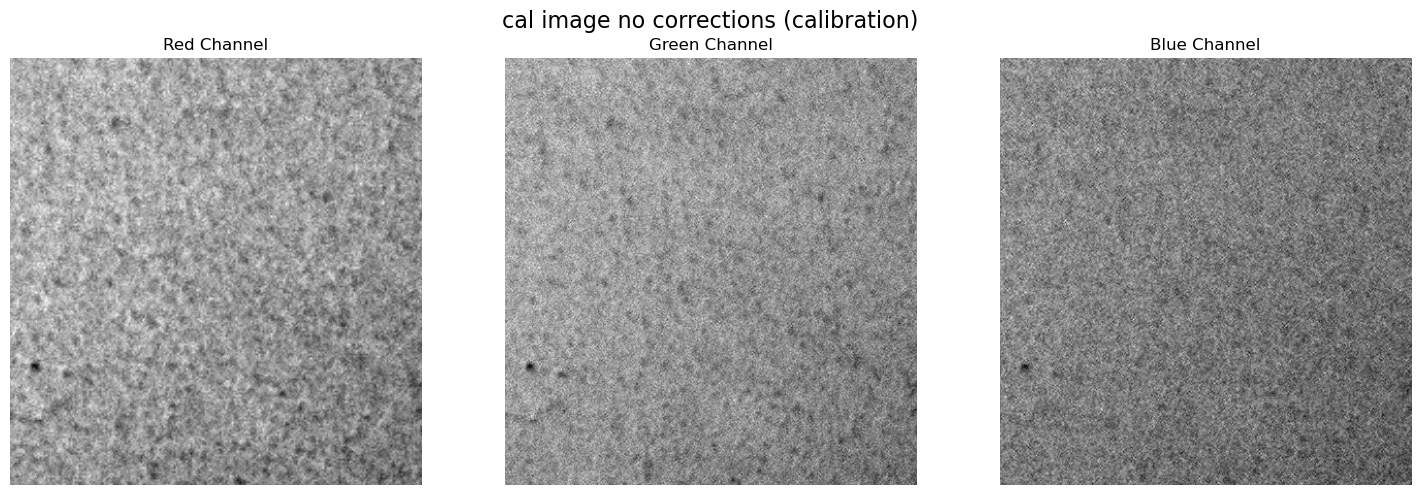

In [6]:
# Load the images
cal_images = io.imread('raw_images\\M18_3_RT_cal_tstep20s.tif')
#first image: t=0s for reference
imcal_int_cal=cal_images[0,:,:,:]
#display R, G and B channel of first image (=cal image)
display_RGB_channels(imcal_int_cal, title='cal image no corrections (calibration)')

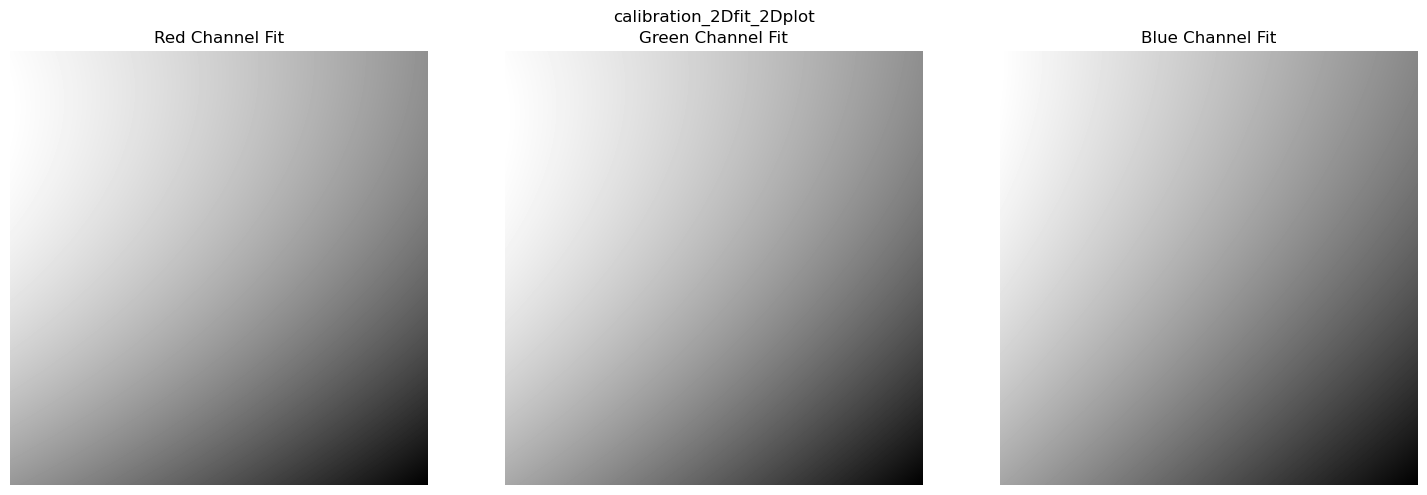

In [ ]:
#polynomial fit to first calibration image
results_cal,Z_fit_combined_cal = polynomialfit_calim(imcal_int_cal, alpha=0.03,title = "calibration")
#correct calibration images for illumination gradient
imcal_factor_cal = Z_fit_combined_cal/np.max(Z_fit_combined_cal, axis=(0,1))
cal_images_corr = cal_images/imcal_factor_cal
#show last calibration image with and without correction
display_RGB_channels(cal_images[-1,:, :, :], title='last cal image before correction')
display_RGB_channels(cal_images_corr[-1,:, :, :], title='last cal image after correction')

In [ ]:
#correct for shift with time with reference to area 3
ref_images_t_cal = io.imread('raw_images\\M18_3_RT_cal_ref.tif')
ref_intensities_t_cal = np.mean(ref_images_t_cal, axis = (1,2))

intshift_factor_cal = int_shift_time(ref_intensities_t_cal, 3,title="cal")
cal_int_noshiftcorr = np.mean(cal_images_corr, axis = (1,2))
cal_int = cal_int_noshiftcorr/intshift_factor_cal

fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].plot(cal_int_noshiftcorr[:,0],cal_int_noshiftcorr[:,1], "o",ms=5, color="#089099", label="no shift correction")
axes[0].plot(cal_int[:,0],cal_int[:,1], "x", ms =5, color="#7c1d6f", label="shift correction")
axes[0].set_xlabel("RED", color='r')
axes[0].set_ylabel("GREEN", color='g')
axes[0].legend()
axes[1].plot(cal_int_noshiftcorr[:,0],cal_int_noshiftcorr[:,2], "o",ms=5, color="#089099", label="no shift correction")
axes[1].plot(cal_int[:,0],cal_int[:,2], "x", ms =5, color="#7c1d6f", label="shift correction")
axes[1].set_xlabel("RED", color='r')
axes[1].set_ylabel("BLUE", color='b')
axes[1].legend()
axes[2].plot(cal_int_noshiftcorr[:,1],cal_int_noshiftcorr[:,2], "o",ms=5, color="#089099", label="no shift correction")
axes[2].plot(cal_int[:,1],cal_int[:,2],  "x", ms =5, color="#7c1d6f", label="shift correction")
axes[2].set_xlabel("GREEN", color='g')
axes[2].set_ylabel("BLUE", color='b')
axes[2].legend()
fig.suptitle(f"cal image correction - intensity shift with time")
plt.show()

### Image corrections of the diffusion images

In [ ]:
# Load the images for different time steps
dif_images = io.imread('raw_images\\M18_3_RT_dif_tsteplog.tif')
dim_height=dif_images.shape[1]

# Calculate average intensity along image height
imcal_int_dif = dif_images[0,:,:,:]
dim_num=imcal_int_dif.shape[0]
dim_width= imcal_int_dif.shape[1]

#define length array
length_pix =np.linspace(0,dim_width,dim_width)
upp = 1/3.52 #=um per pixel
length = length_pix*upp

#display R, G and B channel of first image (=cal image)
display_RGB_channels(imcal_int_dif, title='cal image no corrections (diffusion)')

In [ ]:
#polynomial fit to first calibration image (the whole area is still lithiated)
results_dif,Z_fit_combined_dif = polynomialfit_calim(imcal_int_dif, alpha=0.0055,title="diffusion")
#correct diffusion images for illumination gradient
imcal_factor_dif = Z_fit_combined_dif/np.max(Z_fit_combined_dif, axis=(0,1))
dif_images_corr = dif_images/imcal_factor_dif
#show last calibration image with and without correction
display_RGB_channels(dif_images[1,:, :, :], title='2nd dif image before correction')
display_RGB_channels(dif_images_corr[1,:, :, :], title='2nd dif image after correction')

In [ ]:
#correct for shift in int with time
profile_corr = np.mean(dif_images_corr, axis=1) 
ref_intensities_t_dif = np.mean(profile_corr[:,-400:,:], axis = 1) #choose area in the middle of profile where there is no change expected (area 3)
#apply correction of intensity shift over time
intshift_factor_dif = int_shift_time(ref_intensities_t_dif, 0.0001, title="dif")
profile_corr2 = np.transpose(profile_corr,(1,0,2))/intshift_factor_dif
profile_corr2 = np.transpose(profile_corr2,(1,0,2))
 
plot_profile(length, profile_corr2,25,title="Intensity profiles from concentration gradient over time. Fully corrected.")

## Calculation of effective diffusion coefficient and barrier coefficient

plot the profile with the line that shows how the diffusion front is tracked + determine the intersectionof this threshold with the intensity

In [ ]:
#plot profile with the threshold line for D determination

crop_drop=52 #crop intensity chages due to photo resist edge. Neglect these intensities to make sure they don't disturb the determination of the diffusion width
profile_corr2_crop = profile_corr2[:,crop_drop:,:]
length_crop=length[crop_drop:]
plot_profile(length_crop, profile_corr2_crop,25,title="corrected_cropstart")

threshold = 0.27 #to track the furthest part of the diffusion front
profile_corr2_RGBsum = np.transpose(np.transpose(profile_corr2[:,:,:],(2,0,1))/np.sum(profile_corr2[:,:,:], axis=2),(1,2,0)) 

#make time array (this is a bit complicated because it is logarithmic but it simply gives us an array that give us the time at which the images were recorded)
time_step = 20
start_index = 15
end_index = 2534
n_points = 700
# Generate total time range
n_images = end_index - start_index + 1
max_time = (n_images - 1) * time_step
# Generate log-spaced times from 20 s upward
log_times = np.logspace(np.log10(time_step), np.log10(max_time), n_points)

# Add 0 s manually (for first frame)
times = np.concatenate(([0], log_times))

# Round to nearest multiple of 20 s and deduplicate
dif_time = np.unique(np.round(times / time_step) * time_step)
dif_time = dif_time[dif_time <= max_time]

#generate array that has the diffusion width at which the intensity cross the threshold intensity that is used to track the diffusion front
dif_width_pix = np.argmax(profile_corr2_RGBsum[:,:,1]<threshold, axis=1)
dif_width_um = dif_width_pix*upp


line_val=threshold
num=profile_corr2_RGBsum[:,crop_drop:,:].shape[0]
colorsR = cm.autumn(np.linspace(1, 0, num-1))
colorsG = cm.summer(np.linspace(1, 0, num-1))
colorsB = cm.winter(np.linspace(1, 0, num-1))

x=[(0,length[-1]),(line_val,line_val)]


dif_width_int= np.full(len(dif_width_um),threshold)

for i in range (1,num-2,40):
    
    plt.plot(length_crop, profile_corr2_RGBsum[i,crop_drop:,0], color=colorsR[i])
    plt.plot(length_crop, profile_corr2_RGBsum[i,crop_drop:,1], color=colorsG[i]) 
    plt.plot(length_crop, profile_corr2_RGBsum[i,crop_drop:,2], color=colorsB[i]) 

plt.plot(dif_width_um[::40][1:], dif_width_int[::40][1:], marker='x', color='k')
plt.plot(dif_width_um[-1], dif_width_int[-1], marker='x', color='k')
    
plt.plot(length_crop, profile_corr2_RGBsum[0,crop_drop:,0], color=colorsR[0], label="0 s")
plt.plot(length_crop, profile_corr2_RGBsum[-1,crop_drop:,0], color=colorsR[-1], label=f"{dif_time[-1]/60/60} h")
    
plt.plot(length_crop, profile_corr2_RGBsum[0,crop_drop:,1], color=colorsG[0])
plt.plot(length_crop, profile_corr2_RGBsum[-1,crop_drop:,1], color=colorsG[-1], label=f"{dif_time[-1]/60/60} h")

plt.plot(length_crop, profile_corr2_RGBsum[0,crop_drop:,2], color=colorsB[0])
plt.plot(length_crop, profile_corr2_RGBsum[-1,crop_drop:,2], color=colorsB[-1], label=f"{dif_time[-1]/60/60} h")
    
plt.plot(x[0],x[1], linewidth=1.5, color='k')

    
#make pretty
plt.xlabel('length $z$ [\u03bcm]',fontsize=14)
plt.ylabel('normalized RGB intensities',fontsize=14)
plt.yticks(np.arange(0.15,0.6,0.1), fontsize=14)
plt.xticks(fontsize=14)
plt.xlim([0,270])

plt.show()

Now fit to the determined diffusion width at different times to determine the effective transport coefficients

In [ ]:
#fit linear to parabolic function(diffusional transport + barrier) and purely parabolic (only diffusional) to determine the effective transport coefficeints
def lintopar_fit(t_data, w_data, initial_guess, lower_bounds, upper_bounds):
    def model(w, k, c, D):
        return (1/k)*(w - c) + (1/(2*D))*(w - c)**2

    # Perform the curve fitting
    popt, pcov = curve_fit(model, w_data, t_data, p0=initial_guess, bounds=(lower_bounds, upper_bounds))

    # Extract the optimized parameters
    k_opt, c_opt, D_opt = popt
    print("Optimized parameters:")
    print(f"k = {k_opt:.5f}, c = {c_opt:.5f}, D = {D_opt:.5f}")

    # Compute the fitted curve
    return model(w_data, *popt), k_opt, c_opt, D_opt

t_fit_ltp, k, c, D = lintopar_fit(dif_time, dif_width_um, initial_guess = [0.05, 0.00, 0.37], lower_bounds = [0, -4, 0], upper_bounds = [np.inf, 1.3, np.inf])

# --- model: parabolic growth (w² = 2 D t) ---
def model_par(t, D, c):
    return 2 * D * t + c
#for the parabolic model we only use the last third of the data points because the diffusion is the long term rate determining process
t_data = dif_time[int(0.7*len(dif_time)):]
w2_data = dif_width_um[int(0.7*len(dif_width_um)):]**2

popt, pcov = curve_fit(model_par, t_data, w2_data)
D_opt, c_opt  = popt

# --- compute fitted curve ---
w2_fit = model_par(dif_time, D_opt, c_opt)

##calculate r_squared compared to whole width range for parabolic
SS_res = np.sum([np.sum((dif_width_um**2-w2_fit)**2)])
SS_tot = np.sum([np.sum((dif_width_um**2-[np.mean(dif_width_um**2)])**2)])
rsquared_p = 1 - SS_res/SS_tot
rsquared_p = round(rsquared_p,5)

SS_res = np.sum([np.sum((dif_time-t_fit_ltp)**2)])
SS_tot = np.sum([np.sum((dif_time-[np.mean(dif_time)])**2)])
rsquared_ltp = 1 - SS_res/SS_tot
rsquared_ltp = round(rsquared_ltp,5)

# --- MAIN PLOT (squared data) ---
fig, ax = plt.subplots()
ax.errorbar(dif_time/60**2, dif_width_um**2,xerr=2/60**2, yerr = 2, color='k', marker="s", linestyle='None', capsize=3, elinewidth=1.0, ms=6, label='exp.')
ax.plot(t_fit_ltp/60**2, dif_width_um**2, linewidth=2, color='#fcde9c', label=f'linear to parabolic: R$^2$={np.round(rsquared_ltp,4)}',zorder=20)
ax.plot(dif_time/60**2, w2_fit, linestyle='dashed', linewidth=2, color='#dc3977', label=f'parabolic: R$^2$={np.round(rsquared_p,4)}', zorder=30)

ax.set_xlabel('time $t$ [h]', fontsize=14)
ax.set_ylabel('(length $z$)$^2$ [µm$^2$]', fontsize=14)
ax.tick_params(labelsize=14)
plt.legend(fontsize=11, frameon=False, loc='upper left')
plt.xlim(-2000/60**2,67000/60**2)

# --- INSET (linear data) ---
ax_inset = inset_axes(ax, width="45%", height="40%", bbox_to_anchor=(0.001, 0.15, 1, 1),  bbox_transform=ax.transAxes,loc='lower right', borderpad=0.2)

# Plot linear data
ax_inset.errorbar(dif_time/60**2, dif_width_um**2, xerr=2/60**2, yerr = 2, color='k', marker="s", linestyle='None', capsize=1, elinewidth=0.5, ms=2)
ax_inset.plot(t_fit_ltp/60**2, dif_width_um**2, linewidth=2, color='#fcde9c', zorder=30)
ax_inset.plot(dif_time/60**2, w2_fit, linestyle='dashed', linewidth=2, color='#dc3977', zorder=40) 

# Inset limits
ax_inset.set_xlim(0, 3500/60**2)
ax_inset.set_ylim(0, 50**2)
ax_inset.set_xlabel('$t$ [h]', fontsize=11)
ax_inset.set_ylabel('$z^2$ [µm]', fontsize=11)
ax_inset.tick_params(labelsize=11)


rect_xmin, rect_xmax = 0, 3500/60**2
rect_ymin, rect_ymax = 0**2, 50**2  
ax.add_patch(plt.Rectangle((rect_xmin, rect_ymin),
                           rect_xmax - rect_xmin,
                           rect_ymax - rect_ymin,
                           fill=False, edgecolor='k', linestyle='-', lw=1.0, zorder=60))

plt.show()

## Determination of concentration profiles from the RGB intensities

In the next step we determine the concentration profiles that cause the observed optical change. This is done by training a support vector regression model with the calibration data and then predicting the concentrations at each pixel from the combination of RGB intensities measured at that point in the diffusion image.

First we have to determine some helper functions again:

In [ ]:
#function to plot RGB intensities of the calibration and diffusion measurement to make sure they are comparable
def compare_cal_dif(cal_data, dif_data, time_dif, width_dif, title=None):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot calibration data
    ax.scatter(cal_data[:, 0], cal_data[:, 1], cal_data[:, 2], label='calibration', color="#089099", marker='o', s=3)
    
    # Plot aligned diffusion data
    ax.scatter(dif_data[:, 0], dif_data[:, 1], dif_data[:, 2], label='diffusion', color="#7c1d6f", marker='s', s=3)
    
    ax.set_xlabel('R')
    ax.set_ylabel('G')
    ax.set_zlabel('B')
    ax.set_title(f"\n {title} dif cal int comparison \n dif t = {round(time_dif/60**2,2)} h -> dif width = {round(width_dif,2)} um")
    plt.legend(fontsize=10)
    plt.show()
    
    fig, axes = plt.subplots(1, 3, figsize=(15,5))
    axes[0].plot(cal_data[:,1], cal_data[:,0], "o",ms=5, color="#089099", label='calibration')
    axes[0].plot(dif_data[:,1], dif_data[:,0], "x",ms=5, color="#7c1d6f", label='diffusion')
    axes[0].set_ylabel("RED", color='r', fontsize=20)
    axes[0].set_xlabel("GREEN", color='g', fontsize=20)
    axes[0].legend(framealpha=0, fontsize=20)
    axes[0].tick_params(axis='both', labelsize=20)
    axes[1].plot(cal_data[:,2], cal_data[:,0], "o",ms=5, color="#089099")
    axes[1].plot(dif_data[:,2], dif_data[:,0], "x",ms=5, color="#7c1d6f")
    axes[1].set_ylabel("RED", color='r', fontsize=20)
    axes[1].set_xlabel("BLUE", color='b', fontsize=20)
    #axes[1].legend(fontsize=20)
    axes[1].tick_params(axis='both', labelsize=20)
    axes[2].plot(cal_data[:,2], cal_data[:,1], "o",ms=5, color="#089099")
    axes[2].plot(dif_data[:,2], dif_data[:,1], "x",ms=5, color="#7c1d6f")
    axes[2].set_ylabel("GREEN", color='g', fontsize=20)
    axes[2].set_xlabel("BLUE", color='b', fontsize=20)
    #axes[2].legend(fontsize=20)
    axes[2].tick_params(axis='both', labelsize=20)
    plt.tight_layout()
    fig.suptitle(f"{title} dif cal int comparison \n dif t = {round(time_dif/60**2,2)} h -> dif width = {round(width_dif,2)} um")
    plt.show()

In [ ]:
#training of the support vector regression on the calibration data --> gives us a "function" that describes how the RGB intensities change with change of Li concentration
def ML_training_cal(cal_data, cont, title=None):
    
    #split features (intensities in RGB) into training & test set
    features_train, features_test, cont_train, cont_test = model_selection.train_test_split(cal_data, cont, test_size=0.2, random_state=1)
    svr = SVR(kernel='rbf', gamma=10.0,C=100, tol=0.000001,epsilon=0.001) #svr = SVR(kernel='rbf', gamma='scale', tol=0.000001,epsilon=0.0)
    svr.fit(features_train,cont_train)
    cont_pred=svr.predict(features_test)
    #mean squared error
    mse=mean_squared_error(cont_pred,cont_test) 
    
    
    #plot predictions by test set as well as training data###
    # Plot measured data
    plt.plot(cont,cal_data[:,0],"o", ms=1,  label='measured r', color='r', zorder=2)
    plt.plot(cont,cal_data[:,1],"o", ms=1,  label='measured g', color='g', zorder=2)
    plt.plot(cont,cal_data[:,2],"o", ms=1,  label='measured b', color='b', zorder=2)  
    # Plot scattered points for prediction test set
    plt.scatter(cont_pred,features_test[:,0],  label='prediction test set',  facecolors = 'none',edgecolors='black',linewidths=0.5, alpha =1, s=7, zorder=3)
    plt.scatter(cont_pred, features_test[:,1], facecolors = 'none',edgecolors='black',linewidths=0.5, alpha =1, s= 4, zorder=3)  
    plt.scatter(cont_pred,features_test[:,2],   facecolors = 'none',edgecolors='black',linewidths=0.5, alpha =1, s=4, zorder=3)  
    # make pretty
    plt.xlabel('x in Li$_x$Mn$_2$O$_4$',fontsize=16)
    plt.ylabel('normalized intensities',fontsize=16)
    plt.title(f"{title} \n MSE: {mse}")
    plt.legend()
    plt.show()
    return svr

In [ ]:
#function to predict the concentration along the diffusion profile from the RGB intensities using the SVR model trained on the calibration images
def ML_prediction_dif(dif_data, length, svr, time_dif, width_dif, title=None):
    dif_cont_pred = svr.predict(dif_data)
    
    #plot concentration profile
    
    plt.plot(length,dif_cont_pred,color='k') 
    #make pretty
    plt.xlabel('diffusion length [\u03bcm]',fontsize=16)
    plt.ylabel('x in Li$_x$Mn$_2$O$_4$',fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.title(f"{title} c pred \n dif t = {round(time_dif/60**2,2)} h -> dif width = {round(width_dif,2)} um")
    plt.show()
    
    fig, ax1 = plt.subplots()

    ax1.set_xlabel('diffusion length [\u03bcm]',fontsize=16)
    ax1.set_ylabel('RGB intensities', fontsize=16)
    ax1.scatter(length, dif_data[:,0], color='red', marker='x', s= 1)
    ax1.scatter(length, dif_data[:,1], color='green', marker='x', s= 1)
    ax1.scatter(length, dif_data[:,2], color='blue', marker='x', s= 1)

    ax2 = ax1.twinx()
    ax2.set_ylabel('x in Li$_x$Mn$_2$O$_4$',fontsize=16)
    ax2.plot(length, dif_cont_pred, color='k')
    ax2.tick_params(axis='y', labelcolor='k')
    if title:
        fig.suptitle(f"{title} c pred from int \n dif t = {round(time_dif/60**2,2)} h -> dif width = {round(width_dif,2)} um")
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()
    
    return dif_cont_pred

In [ ]:
#%% calc c profiles
#choose time for concentration profile
index = np.argmax(dif_width_um>150) # you can change this index to do this procedure for diffusion images taken at different times 
dif_time_cvx = dif_time[index]
dif_width_cvx = dif_width_um[index]

#correlate time_CP with Li content
time_CP = 8580 
t_step_CP = 20 
times_CP = np.arange(0, time_CP, t_step_CP)
cont = -1/time_CP*(times_CP-time_CP)
cont=cont.reshape(-1,1)

cont_cal_min = cont[np.argmin(cal_int[:,0])]

#plot corrected "raw" data
compare_cal_dif(cal_int,profile_corr2_crop[index,:,:], dif_time_cvx, dif_width_cvx, "14_raw (corrected)")
###########################################################################################################################
#c prediction by overlapping curves --> this is described in the supplementary material
###########################################################################################################################


dif_int_lith = np.mean(profile_corr2_crop[0,:,:], axis=0)


## normalization 2: linear interpolation between lithiated and delithiated
cal_int_norm2 = (cal_int-cal_int[0,2])/(cal_int[-1,0]-cal_int[0,2]+10**(-20))
#index_delithdet = np.argmax(profile_corr2_crop[index,:,0])


dif_int_delith = np.max(profile_corr2_crop[index,:,:], axis=0)#np.mean(profile_corr2_crop[index,:index_delithdet,:], axis=0) # change this definition according to data
dif_int_norm2 = (cal_int_norm2[-1,:] - cal_int_norm2[0,:])/(dif_int_delith-dif_int_lith)*profile_corr2_crop[index,:,:] + cal_int_norm2[0,:] - (cal_int_norm2[-1,:]-cal_int_norm2[0,:])/(dif_int_delith-dif_int_lith)*dif_int_lith

compare_cal_dif(cal_int_norm2, dif_int_norm2, dif_time_cvx, dif_width_cvx, "comparison after linear interpolation of intensities between lithiated and delithiated state")

svr_norm2 = ML_training_cal(cal_int_norm2, cont, "normalization of intensities by linear interpolation of intensities between lithiated and delithiated state")
dif_cont_pred_norm2 = ML_prediction_dif(dif_int_norm2, length_crop, svr_norm2, dif_time_cvx, dif_width_cvx, "prediction after normalization of intensities by linear interpolation of intensities between lithiated and delithiated state")
###########################################################################################################################
## normalization 3: linear interpolation between lithiated and delithiated & then align min by scaling
#rescaling to align minimum in red intensity, but for each half separately to keep alignment of delith and lith
#define red intensity min
cal_min = np.array([np.min(cal_int_norm2[:,0]), cal_int_norm2[np.argmin(cal_int_norm2[:,0]),1], cal_int_norm2[np.argmin(cal_int_norm2[:,0]),2]])
dif_min = np.array([np.min(dif_int_norm2[:,0]), dif_int_norm2[np.argmin(dif_int_norm2[:,0]),1], dif_int_norm2[np.argmin(dif_int_norm2[:,0]),2]])
dif_argmin = np.argmin(dif_int_norm2[:,0])
#define calibrated int for delith and lith
dif_int_norm2_delith = (cal_int_norm2[-1,:] - cal_int_norm2[0,:])/(dif_int_delith-dif_int_lith)*dif_int_delith + cal_int_norm2[0,:] - (cal_int_norm2[-1,:]-cal_int_norm2[0,:])/(dif_int_delith-dif_int_lith)*dif_int_lith
dif_int_norm2_lith = (cal_int_norm2[-1,:] - cal_int_norm2[0,:])/(dif_int_delith-dif_int_lith)*dif_int_lith + cal_int_norm2[0,:] - (cal_int_norm2[-1,:]-cal_int_norm2[0,:])/(dif_int_delith-dif_int_lith)*dif_int_lith
#determine scaling factors
scalingf_lith = (cal_min - cal_int_norm2[0,:])/(dif_min-dif_int_norm2_lith)
scalingf_delith = (cal_min - cal_int_norm2[-1,:])/(dif_min-dif_int_norm2_delith)

dif_int_norm3 = np.copy(dif_int_norm2)
dif_int_norm3[dif_argmin:,0] = dif_int_norm2_lith[0] + scalingf_lith[0]*(dif_int_norm3[dif_argmin:,0] - dif_int_norm2_lith[0])
dif_int_norm3[:(dif_argmin),0] = dif_int_norm3[dif_argmin,0] + scalingf_delith[0]*(dif_int_norm3[:(dif_argmin),0]-dif_min[0])

cal_int_norm3 = cal_int_norm2
compare_cal_dif(cal_int_norm3, dif_int_norm3, dif_time_cvx, dif_width_cvx, "comparison after additional scaling of the minimum in red intensity")

svr_norm3 = ML_training_cal(cal_int_norm3, cont,"additional scaling of the minimum in red intensity")
dif_cont_pred_norm3 = ML_prediction_dif(dif_int_norm3, length_crop, svr_norm3, dif_time_cvx, dif_width_cvx, "prediction after normalization + scaling of minimum")


Now we have been able to extract the concentration profile from the RGB intensities in the diffusion images!

## Determination of concentration dependen diffusion coefficients

From the concentration profiles we can determine the concentration dependent diffusion coefficient by Boltzmann Matano analysis:

<figure>
  <img src="BoltzmannMatanoeq.png" width="400">
  <figcaption>This equation is also presented in N. Kerner, Y. Joshi, M. Mead, S. Eich, R. Talei, G. Schmitz, Machine learning-assisted measurement of lithium transport using operando optical microscopy, Acta Materialia 270 (2024) 119867. https://doi.org/10.1016/j.actamat.2024.119867.</figcaption>
</figure>

As you can see, the integral and the derivative of the concentration profile is included in this analysis. So, if we simply use the above calculated data points we will get largely varying diffusion coefficients due to the dramatic change in the derivative between single data points (due to noise) that is not representative. Therefore, we need to fit a continuous function to the concentration profiles. This is done with sums of error functions.

Helper functions:

In [ ]:
def G(x, *params):
    """Sum of integrated Gaussian-like functions."""
    y = np.zeros_like(x, dtype=float)
    for i in range(len(params) // 4):
        p1, p2, p3, p4 = params[4*i:4*(i+1)]
        a = np.sqrt(p3)
        integral = (np.sqrt(np.pi) / (2 * a)) * erf(a * (x - p4))
        y += p1 + p2 * integral
    return y


def fit_profile(x_data, y_data, filter_index, window_length, polyorder, n_components, t, initial_guess=None):
    """
    Fit a concentration profile using a sum of integrated Gaussians.

    Parameters
    ----------
    x_data        : array  – spatial coordinates (e.g. length_crop)
    y_data        : array  – raw concentration prediction (e.g. dif_cont_pred_norm3)
    filter_index  : int    – apply Savitzky-Golay only up to this index
    window_length : int    – SG filter window length (odd number)
    polyorder     : int    – SG filter polynomial order
    n_components  : int    – number of Gaussian components in G
    t             : float  – time in seconds (used for D_vc calculation)
    initial_guess : list   – flat list of [p1,p2,p3,p4, ...] per component;
                            auto-generated if None

    Returns
    -------
    popt    : fitted parameters
    cc_fit  : fitted curve on x_data
    Dvc     : diffusion coefficient profile
    mse     : mean squared error (normalised)
    """
    # --- smooth the first part of the signal ---
    y_filtered = np.copy(y_data)
    if filter_index > 0:
        y_filtered[:filter_index] = savgol_filter(y_data[:filter_index], window_length, polyorder)

    # --- initial guess ---
    if initial_guess is None:
        x_centers = np.linspace(x_data.min(), x_data.max(), n_components)
        initial_guess = [val for xc in x_centers for val in [0.0, 1.0, 1.0, xc]]

    # --- fit ---
    popt, _ = curve_fit(G, x_data, y_filtered, p0=initial_guess, maxfev=100_000)
    cc_fit = G(x_data, *popt)

    # --- normalise for MSE and D_vc ---
    cc_min, cc_max = cc_fit.min(), cc_fit.max()
    norm_fit = (cc_fit      - cc_min) / (cc_max - cc_min)
    norm_raw = (y_data      - cc_min) / (cc_max - cc_min)
    mse = mean_squared_error(norm_raw, norm_fit)

    # --- D_vc via Boltzmann-Matano approach ---
    Dvc = np.empty(len(x_data))
    grad = np.gradient(norm_fit)
    for i in range(len(x_data)):
        integral = np.trapz(x_data[i:], x=norm_fit[i:])
        Dvc[i] = integral / (2 * t * grad[i]) if grad[i] != 0 else np.nan

    return popt, cc_fit, Dvc, mse

In [ ]:
#first we determine concentration profiles from the diffusion images at different points in time

profiles = []   # list of dicts: {"t_h": ..., "x": ..., "y": ...}

colors_cpred = cm.binary
norm_color   = plt.Normalize(
    vmin=48 - (200 - 48) / 3,
    vmax=int(np.max(dif_width_um))
)

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(48, int(np.max(dif_width_um)), 15):
    index        = np.argmax(dif_width_um > i)
    dif_time_cvx = dif_time[index]

    # --- normalisation 3 (unchanged from original) ---
    index_delithdet  = 10
    dif_int_delith   = np.mean(profile_corr2_crop[index, :index_delithdet, :], axis=0)
    scale            = (cal_int_norm2[-1, :] - cal_int_norm2[0, :]) / (dif_int_delith - dif_int_lith)

    dif_int_norm2    = scale * profile_corr2_crop[index, :, :] + cal_int_norm2[0, :] - scale * dif_int_lith

    dif_argmin       = np.argmin(dif_int_norm2[:, 0])
    dif_min          = np.array([
        np.min(dif_int_norm2[:, 0]),
        dif_int_norm2[dif_argmin, 1],
        dif_int_norm2[dif_argmin, 2]
    ])

    dif_int_norm2_delith = scale * dif_int_delith + cal_int_norm2[0, :] - scale * dif_int_lith
    dif_int_norm2_lith   = scale * dif_int_lith   + cal_int_norm2[0, :] - scale * dif_int_lith

    scalingf_lith   = (cal_min - cal_int_norm2[0,  :]) / (dif_min - dif_int_norm2_lith)
    scalingf_delith = (cal_min - cal_int_norm2[-1, :]) / (dif_min - dif_int_norm2_delith)

    dif_int_norm3 = np.copy(dif_int_norm2)
    dif_int_norm3[dif_argmin:,    0] = (dif_int_norm2_lith[0]
                                        + scalingf_lith[0] * (dif_int_norm3[dif_argmin:, 0] - dif_int_norm2_lith[0]))
    dif_int_norm3[:dif_argmin,    0] = (dif_int_norm3[dif_argmin, 0]
                                        + scalingf_delith[0] * (dif_int_norm3[:dif_argmin, 0] - dif_min[0]))

    y_pred = svr_norm3.predict(dif_int_norm3)
    t_h    = np.round(dif_time_cvx / 3600, 2)

    profiles.append({"t_h": t_h, "t_s": dif_time_cvx, "x": length_crop.copy(), "y": y_pred.copy()})

    color = colors_cpred(norm_color(i))
    ax.scatter(length_crop, y_pred, label=f"{t_h} h", marker="x", s=1, color=color)

ax.set_title("Time evolution – concentration profile")
ax.set_xlabel("length [μm]", fontsize=16)
ax.set_ylabel(r"x in Li$_x$Mn$_2$O$_4$", fontsize=16)
ax.set_xlim(-10, 260)
ax.tick_params(labelsize=16)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n{len(profiles)} time steps computed and stored.")

In [ ]:
# This cell is just that you get nice fits because we have good starting values (e.g. initial guesses) of the fitting parameters already

fit_params = [
    # --- time step 0 ---
    {
        "filter_index":  10,           # FILL IN
        "window_length": 9,          # FILL IN
        "polyorder":     1,           # FILL IN
        "n_components":  2,           # FILL IN
        "initial_guess": [-0.22067, 0.01867, 0.00569, 37.05501,
0.72296, 0.08281, 0.07121, 44.69072,
],
    },
    # --- time step 1 ---
    {
        "filter_index":  10,           # FILL IN
        "window_length": 9,          # FILL IN
        "polyorder":     1,           # FILL IN
        "n_components":  3,           # FILL IN
        "initial_guess": [-1874.17592, 0.00319, 0.00152, 29.30448,
1518.44581, 0.02039, 0.00748, 52.70309,
356.21569, 0.07104, 0.07535, 59.02062,
],
    },
    # --- time step 2 ---
    {
        "filter_index":  10,           # FILL IN
        "window_length": 9,          # FILL IN
        "polyorder":     1,           # FILL IN
        "n_components":  3,           # FILL IN
        "initial_guess": [16.03671, 0.00248, 0.00079, 41.01563,
189.52075, 0.01789, 0.00647, 64.85978,
-205.06937, 0.06715, 0.06518, 74.03079,
],
    },
    # --- time step 2 ---
    {
        "filter_index":  10,           # FILL IN
        "window_length": 9,          # FILL IN
        "polyorder":     1,           # FILL IN
        "n_components":  3,           # FILL IN
        "initial_guess": [13.42548, 0.00269, 0.00080, 58.34822,
191.28251, 0.01699, 0.00590, 78.39941,
-204.20936, 0.06342, 0.06684, 89.09494,
],
    },
    # --- time step 2 ---
    {
        "filter_index":  10,           # FILL IN
        "window_length": 9,          # FILL IN
        "polyorder":     1,           # FILL IN
        "n_components":  3,           # FILL IN
        "initial_guess": [13.54545, 0.00231, 0.00059, 67.51958,
191.21205, 0.01539, 0.00479, 91.72263,
-204.25828, 0.06349, 0.06804, 104.88312,
],
    },
    # --- time step 2 ---
    {
        "filter_index":  10,           # FILL IN
        "window_length": 9,          # FILL IN
        "polyorder":     1,           # FILL IN
        "n_components":  3,           # FILL IN
        "initial_guess": [14.82393, 0.00216, 0.00048, 76.74117,
190.56948, 0.01387, 0.00408, 104.13505,
-204.89325, 0.06312, 0.06686, 119.02367,
],
    },
    # --- time step 2 ---
    {
        "filter_index":  10,           # FILL IN
        "window_length": 9,          # FILL IN
        "polyorder":     1,           # FILL IN
        "n_components":  3,           # FILL IN
        "initial_guess": [13.52304, 0.00188, 0.00035, 85.11835,
191.19132, 0.01312, 0.00348, 117.08303,
-204.21481, 0.06162, 0.06670, 134.09711,
],
    },
    # --- time step 2 ---
    {
        "filter_index":  10,           # FILL IN
        "window_length": 9,          # FILL IN
        "polyorder":     1,           # FILL IN
        "n_components":  3,           # FILL IN
        "initial_guess": [13.21909, 0.00145, 0.00024, 86.94859,
191.34945, 0.01148, 0.00256, 129.04854,
-204.07106, 0.06127, 0.06297, 149.20475,
],
    },
    # --- time step 2 ---
    {
        "filter_index":  10,           # FILL IN
        "window_length": 9,          # FILL IN
        "polyorder":     1,           # FILL IN
        "n_components":  3,           # FILL IN
        "initial_guess": [9.38055, 0.00124, 0.00020, 89.06072,
193.05915, 0.01056, 0.00199, 141.59954,
-201.94312, 0.05981, 0.06165, 164.34899,
],
    },
    # --- time step 2 ---
    {
        "filter_index":  10,           # FILL IN
        "window_length": 9,          # FILL IN
        "polyorder":     1,           # FILL IN
        "n_components":  3,           # FILL IN
        "initial_guess": [5.57438, 0.00111, 0.00016, 90.73765,
194.98312, 0.00949, 0.00163, 153.68523,
-200.06287, 0.05938, 0.05857, 179.35290,
],
    },
]

In [ ]:
#now we fit the concentration profiles at different times and can directly calculate the corresponding diffusion coefficient by Boltzmann-Matano analysis
fit_results = {}   # filled automatically below

for idx, (p, params) in enumerate(zip(profiles, fit_params)):
    label = f"{p['t_h']} h"
    try:
        popt, cc_fit, Dvc, mse = fit_profile(
            x_data        = p["x"].astype(float),
            y_data        = p["y"].astype(float),
            filter_index  = params["filter_index"],
            window_length = params["window_length"],
            polyorder     = params["polyorder"],
            n_components  = params["n_components"],
            t             = p["t_s"],
            initial_guess = params["initial_guess"],
        )
        fit_results[idx] = {"popt": popt, "cc_fit": cc_fit, "Dvc": Dvc, "mse": mse, "label": label}
        print(f"✅ {label:>10s}  |  MSE (normalised) = {mse:.5f}")
    except Exception as e:
        print(f"❌ {label:>10s}  |  Fit failed: {e}")

print(f"\n{len(fit_results)} / {len(profiles)} fits successful.")

# ── individual plots for each time step ───────────────────────────────────
for idx, r in fit_results.items():
    p = profiles[idx]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].scatter(p["x"], p["y"],  s=4, label="data", alpha=0.6)
    axes[0].plot   (p["x"], r["cc_fit"], lw=2, label="fit", color="red")
    axes[0].set_title(f"Concentration profile – {r['label']}")
    axes[0].set_xlabel("length [μm]", fontsize=13)
    axes[0].set_ylabel(r"x in Li$_x$Mn$_2$O$_4$", fontsize=13)
    axes[0].set_xlim(-10, 260)
    axes[0].legend()

    mask = r["cc_fit"] <= 0.95
    axes[1].plot(r["cc_fit"][mask], r["Dvc"][mask]*10**-8, lw=1.5, color="steelblue") # multiplied by 10**-8 to get the units right (length was in um)
    axes[1].set_title(f"D – {r['label']}")
    axes[1].set_xlabel(r"x in Li$_x$Mn$_2$O$_4$", fontsize=13)
    axes[1].set_ylabel(r"$D$ [cm$^2$/s]", fontsize=13)
    axes[1].set_yscale('log')

    plt.tight_layout()
    plt.show()

In [ ]:
#this is just to plot all the concentration profiles with their fits and corresponding diffusion coefficients in one plot for an overview
if not fit_results:
    print("No fits yet. Run at least one fit in Section 4.")
else:
    cmap   = cm.viridis
    keys   = sorted(fit_results)
    colors = cmap(np.linspace(0, 1, len(keys)))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for color, idx in zip(colors, keys):
        p      = profiles[idx]
        r      = fit_results[idx]
        label  = r["label"]

        axes[0].scatter(p["x"], p["y"],  s=2, alpha=0.4, color=color)
        axes[0].plot   (p["x"], r["cc_fit"], lw=1.5, color=color, label=label)

        mask = r["cc_fit"] <= 0.95
        axes[1].plot(r["cc_fit"][mask], r["Dvc"][mask]*10**-8, lw=1.5, color=color, label=label) # multiplied by 10**-8 to get the units right (length was in um)

    axes[0].set_xlabel("length [μm]", fontsize=14)
    axes[0].set_ylabel(r"x in Li$_x$Mn$_2$O$_4$", fontsize=14)
    axes[0].set_title("Concentration profiles + fits")
    axes[0].set_xlim(-10, 260)
    axes[0].legend(fontsize=9)
    axes[0].tick_params(labelsize=13)

    axes[1].set_xlabel(r"x in Li$_x$Mn$_2$O$_4$", fontsize=14)
    axes[1].set_ylabel(r"$D$ [cm$^2$/s]", fontsize=14)
    axes[1].set_title(r"$D$ – all time steps")
    axes[1].legend(fontsize=9)
    axes[1].tick_params(labelsize=13)
    axes[1].set_yscale('log')

    plt.tight_layout()
    plt.show()

Yay! We have successfully determined the concentration dependent diffusion coefficient at different times from the concentration profiles. Thanks for staying with me for the whole process.

Note 1: For this we didn't take the linear barrier into account anymore even though we established in the determiination of the effectice diffusion coefficient that it is also rate determining. However we assume that this is a valid assumption as we are measuring long diffusion distances (>40 um) in this case and the critical thickness is only around 5 um. (See also paper)

Note 2: In the paper we then took an average of the determined diffusion coefficient of times >3 hrs